<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Sistema_Neuro_Simbolico_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision -q

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

In [3]:
#  MÓDULO NEURONAL — Clasificador de plantas

# Generamos datos sintéticos con 4 características:
# [humedad, temperatura, índice_color_hoja, radiación_solar]
X, y = make_classification(
    n_samples=500, n_features=4, n_informative=3,
    n_redundant=0, n_repeated=0,
    n_classes=3, n_clusters_per_class=1, random_state=42
)

In [4]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, test_size=0.2, random_state=42)

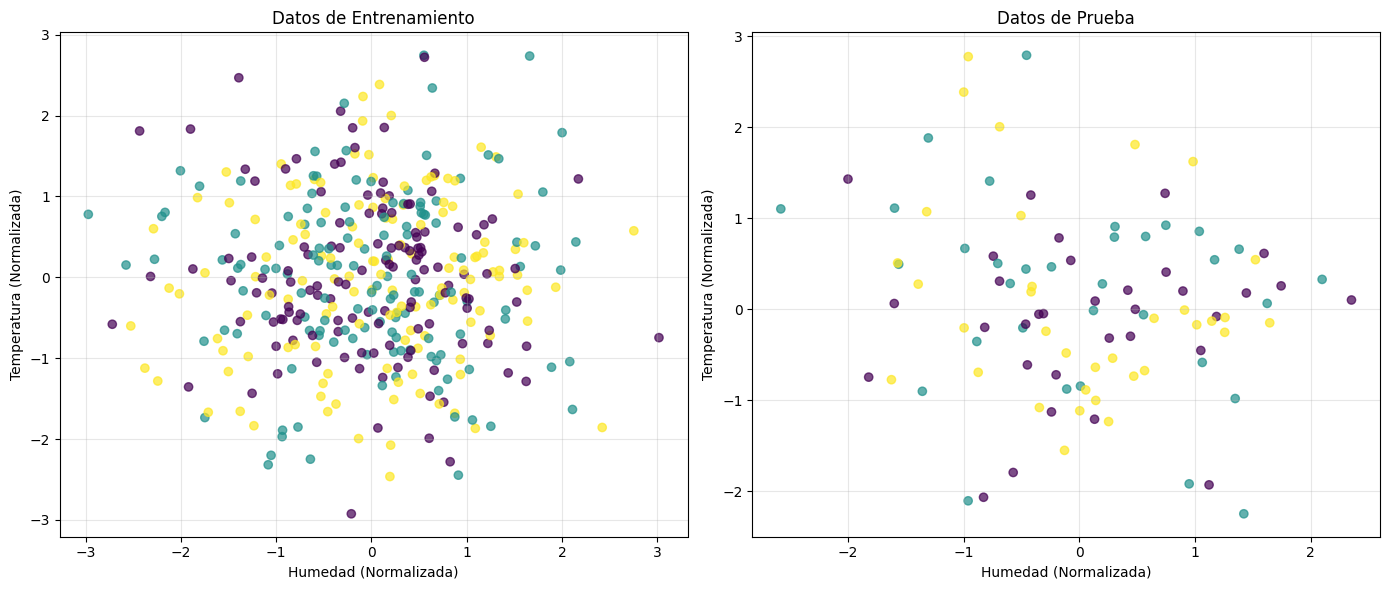

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plotting training data
axes[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='viridis', alpha=0.7)
axes[0].set_xlabel('Humedad (Normalizada)')
axes[0].set_ylabel('Temperatura (Normalizada)')
axes[0].set_title('Datos de Entrenamiento')
axes[0].grid(True, alpha=0.3)

# Plotting test data
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', alpha=0.7)
axes[1].set_xlabel('Humedad (Normalizada)')
axes[1].set_ylabel('Temperatura (Normalizada)')
axes[1].set_title('Datos de Prueba')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Convertir a tensores
X_tr = torch.FloatTensor(X_train)
y_tr = torch.LongTensor(y_train)
X_te = torch.FloatTensor(X_test)
y_te = torch.LongTensor(y_test)

In [7]:
# Red neuronal simple
class PlantClassifier(nn.Module):
    """Red neuronal para clasificar estado de plantas (0=sana, 1=estrés, 2=enferma)"""
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 3)   # 3 clases
        )

    def forward(self, x):
        return self.layers(x)

    def predict_with_confidence(self, x):
        """Devuelve clase predicha y confianza (probabilidad máxima)"""
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs  = F.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)
        return pred.numpy(), conf.numpy(), probs.numpy()

In [8]:
# Entrenamiento
model_neural = PlantClassifier()
optimizer    = torch.optim.Adam(model_neural.parameters(), lr=0.01)
criterion    = nn.CrossEntropyLoss()

In [9]:
losses = []
for epoch in range(200):
    model_neural.train()
    optimizer.zero_grad()
    out  = model_neural(X_tr)
    loss = criterion(out, y_tr)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

In [10]:
# Evaluación
pred_test, conf_test, probs_test = model_neural.predict_with_confidence(X_te)
acc_neural = (pred_test == y_test).mean()
print(f'Red neuronal entrenada — Precisión en test: {acc_neural:.2%}')

Red neuronal entrenada — Precisión en test: 93.00%


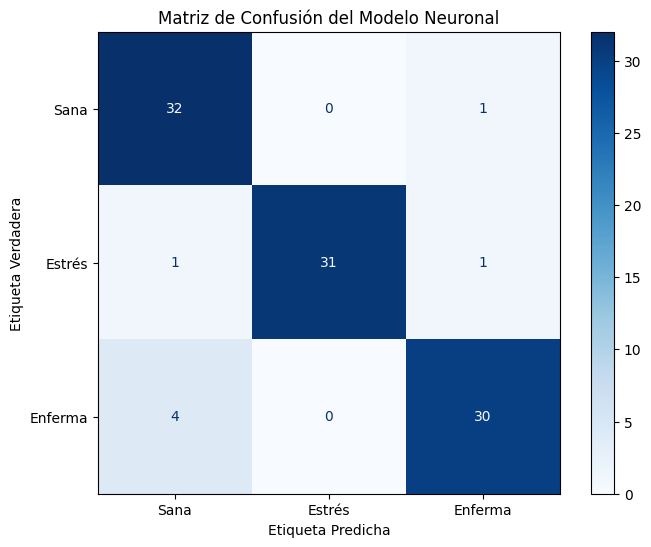

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CLASES = {0: 'Sana', 1: 'Estrés', 2: 'Enferma'}

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, pred_test, labels=np.unique(y_test))

# Obtener los nombres de las clases (si no están ya definidos, usamos los de CLASES)
class_names = [CLASES[i] for i in sorted(CLASES.keys())]

# Visualizar la matriz de confusión
fig, ax = plt.subplots(figsize=(8, 6))
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
display_cm.plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión del Modelo Neuronal')
plt.xlabel('Etiqueta Predicha')
plt.ylabel('Etiqueta Verdadera')
plt.grid(False) # Las matrices de confusión no suelen llevar grid
plt.show()

In [12]:
#  MÓDULO SIMBÓLICO — Motor de reglas lógicas


CLASES = {0: 'Sana', 1: 'Estrés', 2: 'Enferma'}
RIESGO = {0: 'bajo', 1: 'medio', 2: 'alto'}

class MotorDeReglas:
    """
    Motor de inferencia simbólico.
    Recibe la predicción neuronal + características originales
    y aplica reglas expertas para ajustar/enriquecer el diagnóstico.
    """

    def __init__(self, umbral_confianza=0.6):
        self.umbral = umbral_confianza

    def _reglas(self, features, clase_neuronal, confianza):
        """
        Base de reglas (representación simplificada de lógica de primer orden):

        R1: SI confianza < umbral → SOLICITAR_REVISIÓN
        R2: SI humedad < -1.5 AND clase == Sana → RECLASIFICAR como Estrés
        R3: SI temperatura < -1.5 AND color_hoja < -1.0 → ELEVAR riesgo
        R4: SI clase == Enferma AND confianza > 0.8 → CONFIRMADO, riesgo alto
        """
        humedad, temperatura, color_hoja, radiacion = features
        ajustes = []
        clase_final = clase_neuronal

        # R1 — baja confianza
        if confianza < self.umbral:
            ajustes.append('R1: Confianza baja — requiere revisión humana')

        # R2 — sequía severa con diagnóstico erróneo probable
        if humedad < -1.5 and clase_neuronal == 0:
            clase_final = 1
            ajustes.append('R2: Sequía detectada — reclasificada como Estrés')

        # R3 — frío + hoja decolorada
        if temperatura < -1.5 and color_hoja < -1.0:
            if clase_final < 2:
                clase_final = min(clase_final + 1, 2)
            ajustes.append('R3: Frío + decoloración — riesgo elevado')

        # R4 — confirmación de enfermedad
        if clase_neuronal == 2 and confianza > 0.8:
            ajustes.append('R4: Enfermedad confirmada con alta certeza')

        return clase_final, ajustes

    def diagnosticar(self, features_array, clase_neuronal, confianza):
        clase_final, ajustes = self._reglas(features_array, clase_neuronal, confianza)
        return {
            'clase_neuronal': CLASES[clase_neuronal],
            'confianza':      f'{confianza:.1%}',
            'clase_final':    CLASES[clase_final],
            'riesgo':         RIESGO[clase_final],
            'reglas_activas': ajustes if ajustes else ['Ninguna — diagnóstico directo']
        }

In [23]:
# ── Demostración con 5 muestras de test aleatorias ──────────────────────────
motor = MotorDeReglas(umbral_confianza=0.6)

print('=' * 60)
print(' SISTEMA NEURO-SIMBÓLICO — Diagnóstico de Plantas')
print('=' * 60)

# Seleccionar 5 índices aleatorios del conjunto de prueba
random_indices = np.random.choice(len(X_test), 5, replace=False)

for i, idx in enumerate(random_indices):
    features   = X_test[idx]   # características en escala normalizada
    clase_nn   = pred_test[idx]
    conf_nn    = conf_test[idx]
    resultado  = motor.diagnosticar(features, clase_nn, conf_nn)

    print(f'\n Muestra {i+1} (Original index: {idx})')
    print(f'  • Red neuronal → {resultado['clase_neuronal']} ({resultado['confianza']})')
    print(f'  • Diagnóstico simbólico → {resultado['clase_final']} | Riesgo: {resultado['riesgo']}')
    print(f'  • Reglas activas:')
    for r in resultado['reglas_activas']:
        print(f'      {r}')

 SISTEMA NEURO-SIMBÓLICO — Diagnóstico de Plantas

 Muestra 1 (Original index: 19)
  • Red neuronal → Estrés (67.5%)
  • Diagnóstico simbólico → Estrés | Riesgo: medio
  • Reglas activas:
      Ninguna — diagnóstico directo

 Muestra 2 (Original index: 48)
  • Red neuronal → Sana (98.9%)
  • Diagnóstico simbólico → Sana | Riesgo: bajo
  • Reglas activas:
      Ninguna — diagnóstico directo

 Muestra 3 (Original index: 45)
  • Red neuronal → Estrés (99.2%)
  • Diagnóstico simbólico → Estrés | Riesgo: medio
  • Reglas activas:
      Ninguna — diagnóstico directo

 Muestra 4 (Original index: 2)
  • Red neuronal → Sana (49.3%)
  • Diagnóstico simbólico → Sana | Riesgo: bajo
  • Reglas activas:
      R1: Confianza baja — requiere revisión humana

 Muestra 5 (Original index: 8)
  • Red neuronal → Enferma (100.0%)
  • Diagnóstico simbólico → Enferma | Riesgo: alto
  • Reglas activas:
      R4: Enfermedad confirmada con alta certeza


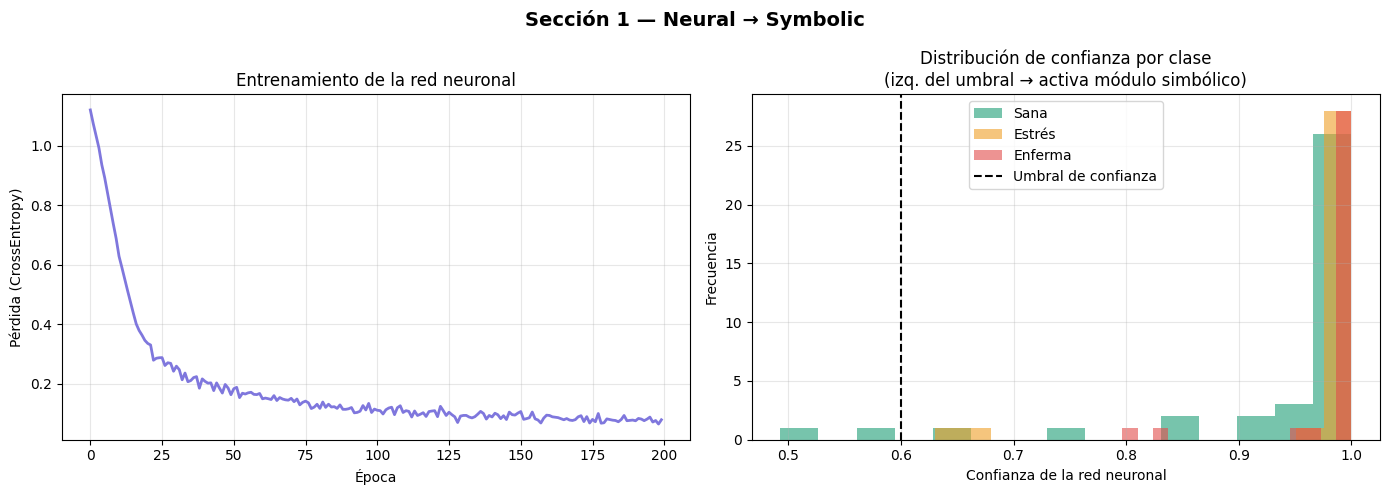

La red tiene 2 muestras con confianza baja que pasan al módulo simbólico


In [24]:
# ── Visualización: Curva de pérdida + comparación de precisiones ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sección 1 — Neural → Symbolic', fontsize=14, fontweight='bold')

# Pérdida de entrenamiento
axes[0].plot(losses, color='#7F77DD', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (CrossEntropy)')
axes[0].set_title('Entrenamiento de la red neuronal')
axes[0].grid(True, alpha=0.3)

# Distribución de confianzas por clase predicha
colores = ['#1D9E75', '#EF9F27', '#E24B4A']
for c, color in enumerate(colores):
    mask = pred_test == c
    if mask.sum() > 0:
        axes[1].hist(conf_test[mask], bins=15, alpha=0.6,
                     color=color, label=CLASES[c])

axes[1].axvline(x=0.6, color='black', linestyle='--', linewidth=1.5, label='Umbral de confianza')
axes[1].set_xlabel('Confianza de la red neuronal')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de confianza por clase\n(izq. del umbral → activa módulo simbólico)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'La red tiene {(conf_test < 0.6).sum()} muestras con confianza baja que pasan al módulo simbólico')